In [23]:
import pandas as pd

# cargar aceleraciones
df_a = pd.read_csv("accel_ang2.csv")

# renombrar columnas
df_a = df_a.rename(columns={
    "inertial-6286.188861:estLinearAccelX": "ax",
    "inertial-6286.188861:estLinearAccelX:valid": "aXvalid",
    "inertial-6286.188861:estLinearAccelY": "ay",
    "inertial-6286.188861:estLinearAccelY:valid": "aYvalid",
    "inertial-6286.188861:estLinearAccelZ": "az",
    "inertial-6286.188861:estLinearAccelZ:valid": "aZvalid",
})

# quedarnos solo con datos válidos
df_a = df_a[
    (df_a["aXvalid"] == 1) &
    (df_a["aYvalid"] == 1) &
    (df_a["aZvalid"] == 1)
]

# df_a.drop(["aZvalid", "aYvalid", "aXvalid"], axis=1)

df_a["time_comp"] = df_a["Time"]*1e-8
df_a["time_comp"] = df_a["time_comp"].astype(int)
df_a["time_comp"] 

df_a["dt"] = df_a["Time"].diff() * 1e-9
# df_u

new_order = ['Time', 'ax', 'ay', 'az', 'dt']
df_a = df_a[new_order]

df_a

,Time,ax,ay,az,dt
0,1771622130451376384,0.003816,0.031436,0.061123,NaN
1,1771622130461423872,0.005611,0.017711,0.056661,0.010047
2,1771622130471371776,0.006301,0.036271,0.061147,0.009948
3,1771622130481222400,0.004411,0.005835,0.034826,0.009851
4,1771622130490975232,-0.007199,0.020422,0.042615,0.009753
...,...,...,...,...,...
2863,1771622159080844032,-0.004404,0.000184,0.032671,0.009791
2864,1771622159090539008,-0.005789,0.007724,0.045007,0.009695
2865,1771622159100142592,0.001703,0.001768,0.038660,0.009604
2866,1771622159109651456,-0.007563,0.005440,0.046788,0.009509


In [24]:
import numpy as np


# Inicializar columnas
for col in ["vx", "vy", "vz", "px", "py", "pz"]:
    df_a[col] = 0.0

p = np.zeros(3)
v = np.zeros(3)

# len(df_a)
for k in range(1, len(df_a)):

    dt = df_a.loc[k, "dt"]

    # Si el primer dt es NaN, lo saltamos
    if pd.isna(dt):
        continue

    a = df_a.loc[k, ["ax", "ay", "az"]].values

    # Velocidad
    v = v + a * dt

    # Posición
    p = p + v * dt

    # Guardar en el DataFrame
    df_a.loc[k, ["vx", "vy", "vz"]] = v
    df_a.loc[k, ["px", "py", "pz"]] = p
    
df_a

,Time,ax,ay,az,dt,vx,vy,vz,px,py,pz
0,1771622130451376384,0.003816,0.031436,0.061123,NaN,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
1,1771622130461423872,0.005611,0.017711,0.056661,0.010047,0.000056,0.000178,0.000569,5.664810e-07,0.000002,0.000006
2,1771622130471371776,0.006301,0.036271,0.061147,0.009948,0.000119,0.000539,0.001178,1.750854e-06,0.000007,0.000017
3,1771622130481222400,0.004411,0.005835,0.034826,0.009851,0.000163,0.000596,0.001521,3.351648e-06,0.000013,0.000032
4,1771622130490975232,-0.007199,0.020422,0.042615,0.009753,0.000092,0.000795,0.001936,4.251768e-06,0.000021,0.000051
...,...,...,...,...,...,...,...,...,...,...,...
2863,1771622159080844032,-0.004404,0.000184,0.032671,0.009791,0.141787,0.104645,1.220248,3.947801e+00,3.034907,18.024576
2864,1771622159090539008,-0.005789,0.007724,0.045007,0.009695,0.141731,0.104720,1.220685,3.949175e+00,3.035922,18.036410
2865,1771622159100142592,0.001703,0.001768,0.038660,0.009604,0.141747,0.104737,1.221056,3.950536e+00,3.036928,18.048137
2866,1771622159109651456,-0.007563,0.005440,0.046788,0.009509,0.141675,0.104789,1.221501,3.951883e+00,3.037924,18.059752


In [25]:
import matplotlib.pyplot as plt

# Tiempo relativo en segundos
t = (df_a["Time"] - df_a["Time"].iloc[0]) * 1e-9

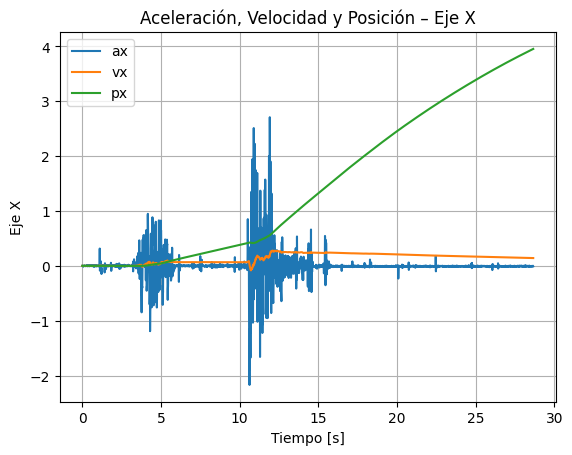

In [26]:
plt.figure()
plt.plot(t, df_a["ax"], label="ax")
plt.plot(t, df_a["vx"], label="vx")
plt.plot(t, df_a["px"], label="px")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje X")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje X")
plt.show()


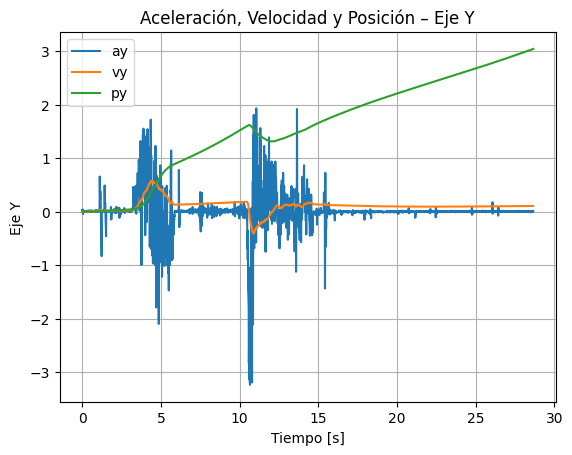

In [27]:
plt.figure()
plt.plot(t, df_a["ay"], label="ay")
plt.plot(t, df_a["vy"], label="vy")
plt.plot(t, df_a["py"], label="py")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje Y")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje Y")
plt.show()


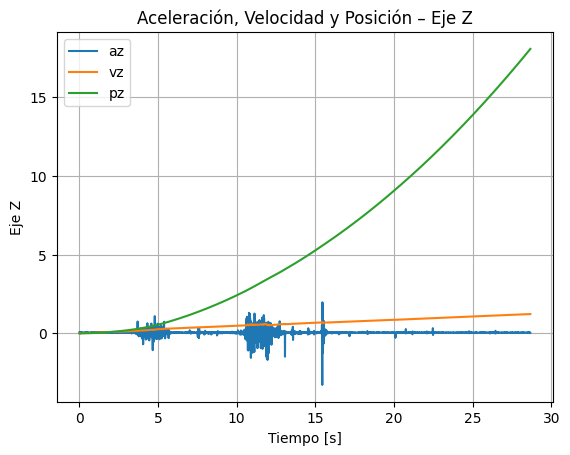

In [28]:
plt.figure()
plt.plot(t, df_a["az"], label="az")
plt.plot(t, df_a["vz"], label="vz")
plt.plot(t, df_a["pz"], label="pz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje Z")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje Z")
plt.show()


In [29]:
import pandas as pd

# cargar aceleraciones
df_a = pd.read_csv("accel_ang2.csv")

# renombrar columnas
df_a = df_a.rename(columns={
    "inertial-6286.188861:estAngularRateX": "arx",
    "inertial-6286.188861:estAngularRateX:valid": "arXvalid",
    "inertial-6286.188861:estAngularRateY": "ary",
    "inertial-6286.188861:estAngularRateY:valid": "arYvalid",
    "inertial-6286.188861:estAngularRateZ": "arz",
    "inertial-6286.188861:estAngularRateZ:valid": "alZvalid",
    "inertial-6286.188861:estLinearAccelX": "alx",
    "inertial-6286.188861:estLinearAccelX:valid": "alXvalid",
    "inertial-6286.188861:estLinearAccelY": "aly",
    "inertial-6286.188861:estLinearAccelY:valid": "alYvalid",
    "inertial-6286.188861:estLinearAccelZ": "alz",
    "inertial-6286.188861:estLinearAccelZ:valid": "alZvalid",
})

# quedarnos solo con datos válidos
# df_a = df_a[
#     (df_a["alXvalid"] == 1) &
#     (df_a["alYvalid"] == 1) &
#     (df_a["alZvalid"] == 1)
# ]

# df_a.drop(["aZvalid", "aYvalid", "aXvalid"], axis=1)

df_a["time_comp"] = df_a["Time"]*1e-8
df_a["time_comp"] = df_a["time_comp"].astype(int)
df_a["time_comp"] 

df_a["dt"] = df_a["Time"].diff() * 1e-9
# df_u

new_order = ['Time', 'arx', 'ary', 'arz', 'alx', 'aly', 'alz','dt']
df_a = df_a[new_order]

df_a

,Time,arx,ary,arz,alx,aly,alz,dt
0,1771622130451376384,0.001582,0.000654,-0.000164,0.003816,0.031436,0.061123,NaN
1,1771622130461423872,0.004586,-0.000865,0.000589,0.005611,0.017711,0.056661,0.010047
2,1771622130471371776,0.010129,-0.001447,-0.000128,0.006301,0.036271,0.061147,0.009948
3,1771622130481222400,0.013006,-0.000776,0.000311,0.004411,0.005835,0.034826,0.009851
4,1771622130490975232,0.010909,-0.000304,-0.000172,-0.007199,0.020422,0.042615,0.009753
...,...,...,...,...,...,...,...,...
2863,1771622159080844032,-0.000142,0.000178,0.000437,-0.004404,0.000184,0.032671,0.009791
2864,1771622159090539008,0.000181,-0.000317,0.000668,-0.005789,0.007724,0.045007,0.009695
2865,1771622159100142592,0.000086,-0.000301,0.000165,0.001703,0.001768,0.038660,0.009604
2866,1771622159109651456,0.000002,0.001927,-0.000566,-0.007563,0.005440,0.046788,0.009509


In [30]:
# solo como comprobación

import numpy as np

dt = df_a['dt'].dropna().values
fs_est = 1 / np.mean(dt)

print("fs estimada:", fs_est, "Hz")

fs estimada: 100.00805612157812 Hz


In [31]:
# import pandas as pd

# # Cargar datos
# data = pd.read_csv("imu_data.csv")

# # Eliminar primera fila (dt = NaN)
# data = data.dropna().reset_index(drop=True)

arx = df_a['arx'].values
ary = df_a['ary'].values
arz = df_a['arz'].values
alx = df_a['alx'].values
aly = df_a['aly'].values
alz = df_a['alz'].values

ang_acc = np.vstack((arx, ary, arz, alx, aly, alz)).T

ang_acc

array([[ 1.58227643e-03,  6.54297997e-04, -1.64052122e-04,
         3.81580670e-03,  3.14364247e-02,  6.11232892e-02],
       [ 4.58560651e-03, -8.65241513e-04,  5.89051051e-04,
         5.61138848e-03,  1.77114215e-02,  5.66613488e-02],
       [ 1.01293838e-02, -1.44746655e-03, -1.27655570e-04,
         6.30054530e-03,  3.62712070e-02,  6.11470789e-02],
       ...,
       [ 8.59697102e-05, -3.00956221e-04,  1.65330130e-04,
         1.70348410e-03,  1.76788727e-03,  3.86596546e-02],
       [ 2.18554555e-06,  1.92726217e-03, -5.66411298e-04,
        -7.56250136e-03,  5.43988124e-03,  4.67879586e-02],
       [ 2.51541875e-04, -4.34103771e-04,  1.45477371e-03,
        -1.00328540e-02,  6.27174554e-03,  2.76207905e-02]],
      shape=(2868, 6))

In [32]:
import numpy as np
from scipy.signal import butter, sosfilt

fs = 100.0      # Hz
fc = 10.0       # Hz
order = 4

Wn = fc / (fs / 2)

sos = butter(order, Wn, btype='low', output='sos')
print(sos)

accel_filt = sosfilt(sos, ang_acc, axis=0)
accel_filt

[[ 0.00482434  0.00964869  0.00482434  1.         -1.04859958  0.29614036]
 [ 1.          2.          1.          1.         -1.32091343  0.63273879]]


array([[ 7.63344476e-06,  3.15655820e-06, -7.91443766e-07,
         1.84087617e-05,  1.51660107e-04,  2.94879734e-04],
       [ 7.07438660e-05,  1.59315163e-05, -2.19932684e-06,
         1.44326112e-04,  1.05144700e-03,  2.15159410e-03],
       [ 3.33123263e-04,  2.57050811e-05,  2.62267935e-06,
         5.48518561e-04,  3.56720693e-03,  7.57357004e-03],
       ...,
       [ 6.45275404e-04,  1.07392819e-04, -1.62225063e-04,
        -7.59428940e-03, -9.16705787e-04,  4.42353240e-02],
       [ 6.45936359e-04,  1.17048906e-04, -1.96731284e-04,
        -5.97103907e-03, -1.52544786e-03,  4.25313542e-02],
       [ 5.55254241e-04,  1.48896309e-04, -1.18133252e-04,
        -4.50689882e-03, -1.06683643e-03,  4.08037704e-02]],
      shape=(2868, 6))

In [33]:
from scipy.signal import butter, filtfilt

def butter_lowpass(fc, fs, order=4):
    wn = fc / (fs / 2)
    b, a = butter(order, wn, btype='low')
    return b, a

fc = 10  # Hz
b, a = butter_lowpass(fc, fs, order=4)

arx_f = filtfilt(b, a, arx)
ary_f = filtfilt(b, a, ary)
arz_f = filtfilt(b, a, arz)
alx_f = filtfilt(b, a, alx)
aly_f = filtfilt(b, a, aly)
alz_f = filtfilt(b, a, alz)
arx_f

array([0.00159218, 0.00479533, 0.00723775, ..., 0.00029536, 0.00026163,
       0.00025063], shape=(2868,))

In [34]:
arx

array([1.58227643e-03, 4.58560651e-03, 1.01293838e-02, ...,
       8.59697102e-05, 2.18554555e-06, 2.51541875e-04], shape=(2868,))

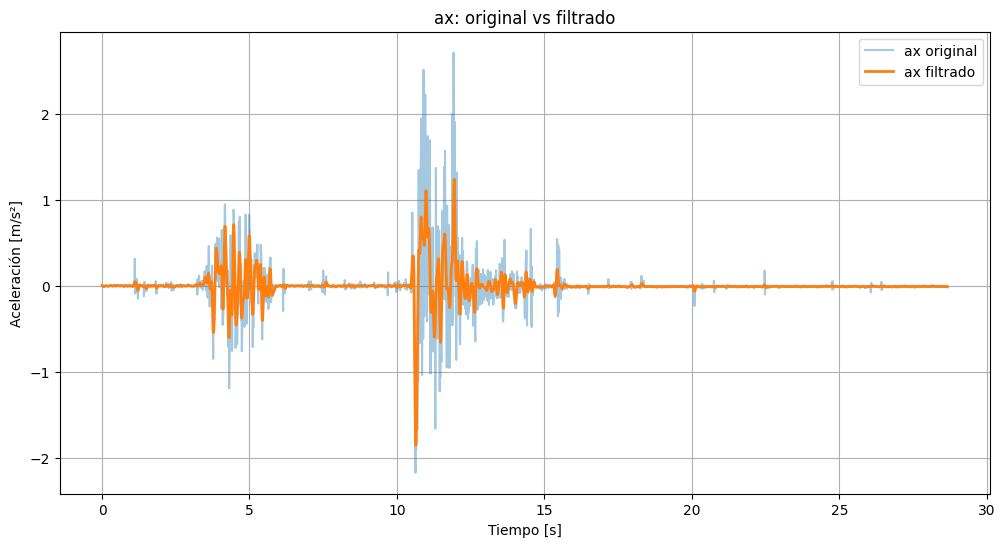

In [35]:
import matplotlib.pyplot as plt

# t = np.cumsum(dt)
N = len(alx)
t = np.arange(N) / fs

plt.figure(figsize=(12,6))
plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, alx_f, label='ax filtrado', linewidth=2)
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración [m/s²]")
plt.title("ax: original vs filtrado")
plt.legend()
plt.grid()
plt.show()

In [36]:
df_a['arx_f'] = arx_f
df_a['ary_f'] = ary_f
df_a['arz_f'] = arz_f
df_a['alx_f'] = alx_f
df_a['aly_f'] = aly_f
df_a['alz_f'] = alz_f
df_a

,Time,arx,ary,arz,alx,aly,alz,dt,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1771622130451376384,0.001582,0.000654,-0.000164,0.003816,0.031436,0.061123,NaN,0.001592,0.000667,-0.000169,0.003866,0.031384,0.061156
1,1771622130461423872,0.004586,-0.000865,0.000589,0.005611,0.017711,0.056661,0.010047,0.004795,0.000100,-0.000104,0.002268,0.023262,0.052669
2,1771622130471371776,0.010129,-0.001447,-0.000128,0.006301,0.036271,0.061147,0.009948,0.007238,-0.000362,-0.000063,0.000430,0.015257,0.044974
3,1771622130481222400,0.013006,-0.000776,0.000311,0.004411,0.005835,0.034826,0.009851,0.008402,-0.000644,-0.000057,-0.001685,0.007712,0.038827
4,1771622130490975232,0.010909,-0.000304,-0.000172,-0.007199,0.020422,0.042615,0.009753,0.008161,-0.000726,-0.000080,-0.003858,0.001283,0.034791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2863,1771622159080844032,-0.000142,0.000178,0.000437,-0.004404,0.000184,0.032671,0.009791,0.000446,0.000282,-0.000171,-0.003642,-0.000371,0.042063
2864,1771622159090539008,0.000181,-0.000317,0.000668,-0.005789,0.007724,0.045007,0.009695,0.000360,0.000232,0.000064,-0.003734,0.000866,0.039686
2865,1771622159100142592,0.000086,-0.000301,0.000165,0.001703,0.001768,0.038660,0.009604,0.000295,0.000091,0.000436,-0.004974,0.002498,0.036376
2866,1771622159109651456,0.000002,0.001927,-0.000566,-0.007563,0.005440,0.046788,0.009509,0.000262,-0.000137,0.000916,-0.007207,0.004343,0.032213


In [37]:
import numpy as np

# Inicializar columnas
for col in ["vx", "vy", "vz", "px", "py", "pz"]:
    df_a[col] = 0.0

p = np.zeros(3)
v = np.ones(3)

# Umbrales
ACC_TH = 0.1       # m/s^2
GYRO_TH = np.deg2rad(1.0)  # rad/s

print(v.shape)
print(df_a.loc[k, ["vx", "vy", "vz"]].shape)
# len(df_a)

a = df_a.loc[2, ["alx", "aly", "alz"]].values
a.shape

v.shape
dt = 0.01
# np.zeros(3).shape

a = df_a.loc[2, ["alx", "aly", "alz"]].values
print(a, a.shape)

print(v, v.shape)

x = v + a#*dt
x

(3,)
(3,)
[0.00630055 0.03627121 0.06114708] (3,)
[1. 1. 1.] (3,)


array([1.00630055, 1.03627121, 1.06114708])

In [38]:
for k in range(0, len(df_a)):

    # dt = df_a.loc[k, "dt"]
    dt = 0.01

    # Si el primer dt es NaN, lo saltamos
    if pd.isna(dt):
        continue

    a = df_a.loc[k, ["alx", "aly", "alz"]].values
    g = df_a.loc[k, ["arx", "ary", "arz"]].values

    # Velocidad
    v = v + a * dt

    # Posición
    p = p + v * dt

    # print(df_a.loc[k, ["vx", "vy", "vz"]].shape)
    # Detección ZUPT
    # if np.linalg.norm(acc[k]) < ACC_TH and np.linalg.norm(gyro[k]) < GYRO_TH:
    if np.linalg.norm(a) < ACC_TH and np.linalg.norm(g) < GYRO_TH:
        v = np.zeros(3)   # ZUPT duro

    # Guardar en el DataFrame
    # print(df_a.loc[k, ["vx", "vy", "vz"]].shape)
    df_a.loc[k, ["vx", "vy", "vz"]] = v
    df_a.loc[k, ["px", "py", "pz"]] = p
    
df_a

,Time,arx,ary,arz,alx,aly,alz,dt,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f,vx,vy,vz,px,py,pz
0,1771622130451376384,0.001582,0.000654,-0.000164,0.003816,0.031436,0.061123,NaN,0.001592,0.000667,-0.000169,0.003866,0.031384,0.061156,0.0,0.0,0.0,0.010000,0.010003,0.010006
1,1771622130461423872,0.004586,-0.000865,0.000589,0.005611,0.017711,0.056661,0.010047,0.004795,0.000100,-0.000104,0.002268,0.023262,0.052669,0.0,0.0,0.0,0.010001,0.010005,0.010012
2,1771622130471371776,0.010129,-0.001447,-0.000128,0.006301,0.036271,0.061147,0.009948,0.007238,-0.000362,-0.000063,0.000430,0.015257,0.044974,0.0,0.0,0.0,0.010002,0.010009,0.010018
3,1771622130481222400,0.013006,-0.000776,0.000311,0.004411,0.005835,0.034826,0.009851,0.008402,-0.000644,-0.000057,-0.001685,0.007712,0.038827,0.0,0.0,0.0,0.010002,0.010009,0.010021
4,1771622130490975232,0.010909,-0.000304,-0.000172,-0.007199,0.020422,0.042615,0.009753,0.008161,-0.000726,-0.000080,-0.003858,0.001283,0.034791,0.0,0.0,0.0,0.010001,0.010011,0.010026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2863,1771622159080844032,-0.000142,0.000178,0.000437,-0.004404,0.000184,0.032671,0.009791,0.000446,0.000282,-0.000171,-0.003642,-0.000371,0.042063,0.0,0.0,0.0,0.403133,-0.019873,0.404624
2864,1771622159090539008,0.000181,-0.000317,0.000668,-0.005789,0.007724,0.045007,0.009695,0.000360,0.000232,0.000064,-0.003734,0.000866,0.039686,0.0,0.0,0.0,0.403133,-0.019873,0.404628
2865,1771622159100142592,0.000086,-0.000301,0.000165,0.001703,0.001768,0.038660,0.009604,0.000295,0.000091,0.000436,-0.004974,0.002498,0.036376,0.0,0.0,0.0,0.403133,-0.019872,0.404632
2866,1771622159109651456,0.000002,0.001927,-0.000566,-0.007563,0.005440,0.046788,0.009509,0.000262,-0.000137,0.000916,-0.007207,0.004343,0.032213,0.0,0.0,0.0,0.403132,-0.019872,0.404637


In [39]:
import matplotlib.pyplot as plt

# Tiempo relativo en segundos
t = (df_a["Time"] - df_a["Time"].iloc[0]) * 1e-9

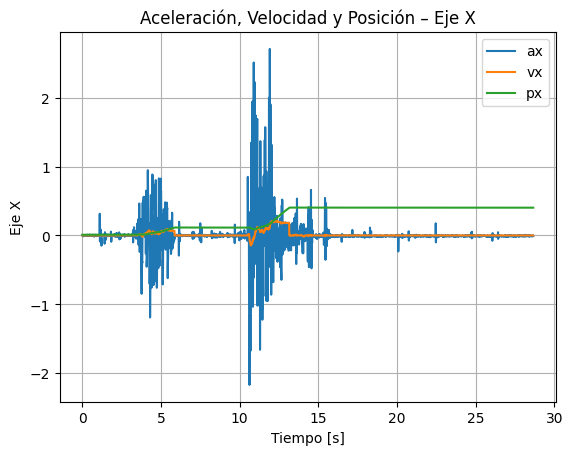

In [40]:
plt.figure()
plt.plot(t, df_a["alx"], label="ax")
plt.plot(t, df_a["vx"], label="vx")
plt.plot(t, df_a["px"], label="px")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje X")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje X")
plt.show()

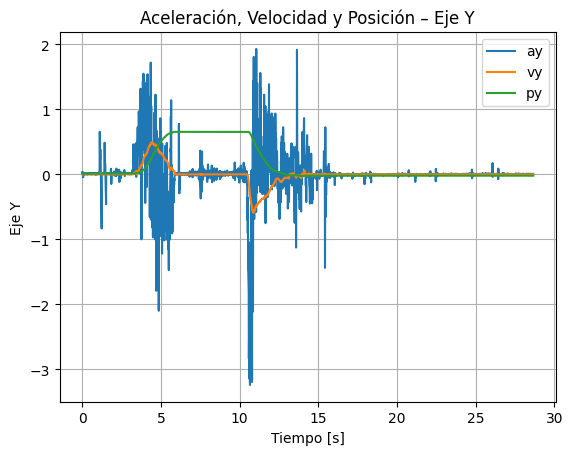

In [41]:
plt.figure()
plt.plot(t, df_a["aly"], label="ay")
plt.plot(t, df_a["vy"], label="vy")
plt.plot(t, df_a["py"], label="py")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje Y")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje Y")
plt.show()

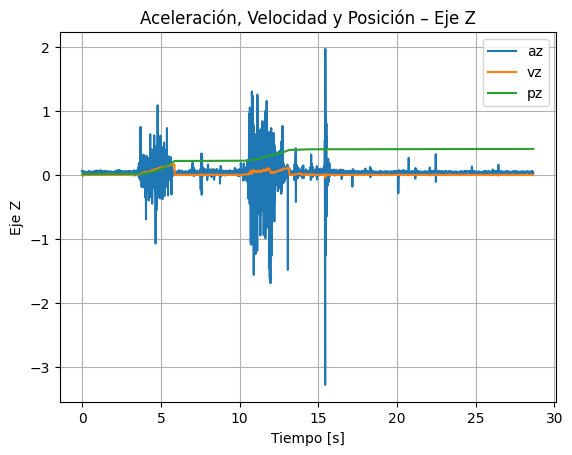

In [42]:
plt.figure()
plt.plot(t, df_a["alz"], label="az")
plt.plot(t, df_a["vz"], label="vz")
plt.plot(t, df_a["pz"], label="pz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje Z")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje Z")
plt.show()

In [43]:
EPS_ACCEL = 0.1      # m/s^2
VAR_ACCEL = 0.02     # (m/s^2)^2
MIN_SAMPLES = int(1.0 * fs)

zupt = np.zeros(len(accel_filt), dtype=bool)
counter = 0

for k in range(N, len(accel_filt)):
    acc_win = accel_filt[k-N:k]
    
    acc_var = np.mean(np.var(acc_win, axis=0))
    acc_dev = abs(acc_norm[k] - g)

    stationary = (
        acc_dev < EPS_ACCEL and
        acc_var < VAR_ACCEL
    )

    if stationary:
        counter += 1
        if counter >= MIN_SAMPLES:
            zupt[k] = True
    else:
        counter = 0

In [44]:
import numpy as np

N = len(acc)

v = np.zeros((N, 3))
p = np.zeros((N, 3))

# Umbrales
ACC_TH = 0.1       # m/s^2
GYRO_TH = np.deg2rad(1.0)  # rad/s

for k in range(1, N):
    # Integración normal
    v[k] = v[k-1] + acc[k] * dt
    p[k] = p[k-1] + v[k] * dt

    # Detección ZUPT
    if np.linalg.norm(acc[k]) < ACC_TH and np.linalg.norm(gyro[k]) < GYRO_TH:
        v[k] = np.zeros(3)   # ZUPT duro

NameError: name 'acc' is not defined

In [ ]:
from scipy.signal import sosfilt

# gyro_filt = sosfilt(sos, gyro_raw)
accel_filt = sosfilt(sos, accel_raw)

In [ ]:
from scipy.signal import sosfiltfilt

gyro_filt = sosfiltfilt(sos, gyro_raw)

In [ ]:
import pandas as pd

def match_quat_accel():
    # --- cargar cuaterniones ---
    df_q = pd.read_csv("quat3.csv")

    df_q = df_q.rename(columns={
        "inertial-6286.188861:estOrientQuaternion[0-0]": "q0",
        "inertial-6286.188861:estOrientQuaternion[0-1]": "q1",
        "inertial-6286.188861:estOrientQuaternion[0-2]": "q2",
        "inertial-6286.188861:estOrientQuaternion[0-3]": "q3",
        "inertial-6286.188861:estOrientQuaternion:valid": "qValid",
    })

    # Comprobar si es un valor válido
    # df_q = df_q[df_q["inertial-6286.188861:estOrientQuaternion:valid"] == 1]

    # df_q["dt"] = df_q["Time"].diff() * 1e-9
    # print(df_q)

    df_q["time_comp"] = df_q["Time"] * 1e-8
    df_q["time_comp"] = df_q["time_comp"].astype(int)
    df_q["time_comp"]

    # df_q

    df_q["time_comp"] = df_q["Time"] * 1e-8
    df_q["time_comp"] = df_q["time_comp"].astype(int)
    df_q["time_comp"]

    # cargar aceleraciones
    df_a = pd.read_csv("accel3.csv")

    # renombrar columnas
    df_a = df_a.rename(columns={
        "inertial-6286.188861:estLinearAccelX": "ax",
        "inertial-6286.188861:estLinearAccelX:valid": "aXvalid",
        "inertial-6286.188861:estLinearAccelY": "ay",
        "inertial-6286.188861:estLinearAccelY:valid": "aYvalid",
        "inertial-6286.188861:estLinearAccelZ": "az",
        "inertial-6286.188861:estLinearAccelZ:valid": "aZvalid",
    })

    # quedarnos solo con datos válidos
    df_a = df_a[
        (df_a["aXvalid"] == 1) &
        (df_a["aYvalid"] == 1) &
        (df_a["aZvalid"] == 1)
    ]

    # df_a.drop(["aZvalid", "aYvalid", "aXvalid"], axis=1)

    df_a["time_comp"] = df_a["Time"]*1e-8
    df_a["time_comp"] = df_a["time_comp"].astype(int)
    df_a["time_comp"] 

    # df_a

    df_u = pd.merge(
        df_q,
        df_a,
        on="time_comp",
        how="inner"
    )
    # df_u

    df_u = df_u.rename(columns={"Time_x": "time"})
    df_u.drop(["Time_y"], axis=1, inplace=True)
    # df_u

    df_u["dt"] = df_u["time"].diff() * 1e-9
    # df_u

    new_order = ['time', 'q0', 'q1', 'q2', 'q3', 'ax', 'ay', 'az', 'dt']
    df_u = df_u[new_order]
    # print(df_u)
    return df_u

df = match_quat_accel()
# print(df)
df



In [ ]:


''''''
# # print(len(df))
# for i in range(len(df)):
#     time = df.loc[i, "time"]
#     dt = df.loc[i, "dt"]
#     q  = df.loc[i, ["q0","q1","q2","q3"]].values
#     a_b = df.loc[i, ["ax","ay","az"]].values
#     print(time, dt, q, a_b, "\n")

# print(dt, q, a_b)

# for cada instante k:
#     leer a_body(k)
#     leer q(k)


#     # from scipy.spatial.transform import Rotation as R

#     # r = R.from_quat([qx, qy, qz, q0])
#     # a_nav = r.as_matrix().T @ a_body

#     R = R(q)
#     a_nav = R^T a_body

#     # v = v + a_nav * dt
#     v(k) = v(k-1) + a_nav * dt

#     # p = p + v * dt
#     p(k) = p(k-1) + v(k) * dt

# interp_quaternion()

import numpy as np
from scipy.spatial.transform import Rotation as R

def ins_step(p, v, q, a_body, dt):
    """
    p      : posición inercial actual (3,)
    v      : velocidad inercial actual (3,)
    q      : cuaternión [q0, qx, qy, qz] (AHRS)
    a_body : aceleración lineal en body frame (3,)
    dt     : paso de tiempo [s]

    devuelve:
    p_new, v_new
    """

    # 1) Normalizar cuaternión (seguridad numérica)
    q = q / np.linalg.norm(q)

    # 2) Rotación body → inercial (pasiva)
    r = R.from_quat([q[1], q[2], q[3], q[0]])
    R_nb = r.as_matrix().T   # body → nav

    # 3) Aceleración en marco inercial
    a_nav = R_nb @ a_body

    # 4) Integración aceleración → velocidad
    v_new = v + a_nav * dt

    # 5) Integración velocidad → posición
    p_new = p + v_new * dt

    return p_new, v_new


'''N = 10
dt = 0.1

df = pd.DataFrame({
    "time": np.arange(N) * dt,
    "dt": [dt]*N,
    "q0": [1]*N,
    "q1": [0]*N,
    "q2": [0]*N,
    "q3": [0]*N,
    "ax": [0]*N,
    "ay": [0]*N,
    "az": [0]*N,
})'''


# a = 1.0  # m/s^2
# dt = 0.1
# N = 10

'''df = pd.DataFrame({
    "time": np.arange(N) * dt,
    "dt": [dt]*N,
    "q0": [1]*N,
    "q1": [0]*N,
    "q2": [0]*N,
    "q3": [0]*N,
    "ax": [a]*N,
    "ay": [0]*N,
    "az": [0]*N,
})'''


'''from math import sqrt

q0 = sqrt(2)/2
qz = sqrt(2)/2

df = pd.DataFrame({
    "time": np.arange(N) * dt,
    "dt": [dt]*N,
    "q0": [q0]*N,
    "q1": [0]*N,
    "q2": [0]*N,
    "q3": [qz]*N,
    "ax": [1]*N,   # acelera en X-body
    "ay": [0]*N,
    "az": [0]*N,
})'''


p = np.zeros(3)
v = np.zeros(3)

for k in range(1, len(df)):

    # dt = t[k] - t[k-1]
    time = df.loc[k, "time"]
    dt = df.loc[k, "dt"]
    quat  = df.loc[k, ["q0","q1","q2","q3"]].values
    a_body = df.loc[k, ["ax","ay","az"]].values

    p, v = ins_step(p, v, quat, a_body, dt)

    # print(f"t={time[k]:.3f}  p={p}  v={v}")
    print(f"t={time:.3f}  v={v}  p={p}")

    # print(dt, q, a_b, "\n")

In [ ]:
import pandas as pd
import numpy as np

# --- cargar cuaterniones ---
df_q = pd.read_csv(
    "cuaterniones2.csv",
    parse_dates=["Time"],
    dayfirst=True
)

df_q = df_q.rename(columns={
    "inertial-6286.188861:estOrientQuaternion[0-0]": "q0",
    "inertial-6286.188861:estOrientQuaternion[0-1]": "q1",
    "inertial-6286.188861:estOrientQuaternion[0-2]": "q2",
    "inertial-6286.188861:estOrientQuaternion[0-3]": "q3",
})

df_q = df_q[df_q["inertial-6286.188861:estOrientQuaternion:valid"] == 1]

print(df_q)



# cargar aceleraciones
df_a = pd.read_csv("accel2.csv")

# renombrar columnas
df_a = df_a.rename(columns={
    "inertial-6286.188861:estLinearAccelX": "ax",
    "inertial-6286.188861:estLinearAccelY": "ay",
    "inertial-6286.188861:estLinearAccelZ": "az",
})

# quedarnos solo con datos válidos
df_a = df_a[
    (df_a["inertial-6286.188861:estLinearAccelX:valid"] == 1) &
    (df_a["inertial-6286.188861:estLinearAccelY:valid"] == 1) &
    (df_a["inertial-6286.188861:estLinearAccelZ:valid"] == 1)
]

# # asegurar tipo entero
# df_a["Time"] = df_a["Time"].astype(np.int64)

# # ordenar por tiempo (por seguridad)
# df_a = df_a.sort_values("Time").reset_index(drop=True)

# delta tiempo en segundos
df_a["dt"] = df_a["Time"].diff() * 1e-9

df_a["time_comp"] = df_a["Time"]*1e-8

print(df_a["time_comp"])

df_a = df_a.dropna().reset_index(drop=True)

print(df_a)




# df = pd.merge(
#     df_q,
#     df_a,
#     on="Time",
#     how="inner"
# )

# df = df.sort_values("Time").reset_index(drop=True)
# df["dt"] = df["Time"].diff() * 1e-9
# df = df.dropna().reset_index(drop=True)

# df

In [ ]:
# --- cargar cuaterniones ---
df_q = pd.read_csv("cuaterniones2.csv")

df_q = df_q.rename(columns={
    "inertial-6286.188861:estOrientQuaternion[0-0]": "q0",
    "inertial-6286.188861:estOrientQuaternion[0-1]": "q1",
    "inertial-6286.188861:estOrientQuaternion[0-2]": "q2",
    "inertial-6286.188861:estOrientQuaternion[0-3]": "q3",
    "inertial-6286.188861:estOrientQuaternion:valid": "qValid",
})

# Comprobar si es un valor válido
# df_q = df_q[df_q["inertial-6286.188861:estOrientQuaternion:valid"] == 1]

# df_q["dt"] = df_q["Time"].diff() * 1e-9
# print(df_q)

df_q["time_comp"] = df_q["Time"] * 1e-8
df_q["time_comp"] = df_q["time_comp"].astype(int)
df_q["time_comp"]

df_q

In [ ]:
df_q["time_comp"] = df_q["Time"] * 1e-8
df_q["time_comp"] = df_q["time_comp"].astype(int)
df_q["time_comp"]

In [ ]:
# cargar aceleraciones
df_a = pd.read_csv("accel2.csv")

# renombrar columnas
df_a = df_a.rename(columns={
    "inertial-6286.188861:estLinearAccelX": "ax",
    "inertial-6286.188861:estLinearAccelX:valid": "aXvalid",
    "inertial-6286.188861:estLinearAccelY": "ay",
    "inertial-6286.188861:estLinearAccelY:valid": "aYvalid",
    "inertial-6286.188861:estLinearAccelZ": "az",
    "inertial-6286.188861:estLinearAccelZ:valid": "aZvalid",
})

# quedarnos solo con datos válidos
df_a = df_a[
    (df_a["aXvalid"] == 1) &
    (df_a["aYvalid"] == 1) &
    (df_a["aZvalid"] == 1)
]

# df_a.drop(["aZvalid", "aYvalid", "aXvalid"], axis=1)

df_a["time_comp"] = df_a["Time"]*1e-8
df_a["time_comp"] = df_a["time_comp"].astype(int)
df_a["time_comp"] 

df_a

In [ ]:
df_u = pd.merge(
    df_q,
    df_a,
    on="time_comp",
    how="inner"
)
df_u

In [ ]:
df_u = df_u.rename(columns={"Time_x": "time"})
df_u

In [ ]:
# df_u.drop(["Time_y"], axis=1, inplace=True)
df_u

In [ ]:
df_u["dt"] = df_u["time"].diff() * 1e-9
df_u

In [ ]:
new_order = ['time', 'q0', 'q1', 'q2', 'q3', 'az', 'ax', 'ay', 'dt']
df_u = df_u[new_order]
df_u

In [ ]:
print(len(df))
for k in range(len(df)):
    # print(k)
    # it = df_u.iloc[0].index
    dt = df_u.loc[k, "dt"]
    q  = df_u.loc[k, ["q0","q1","q2","q3"]].values
    a_b = df_u.loc[k, ["ax","ay","az"]].values
    print(dt, q, a_b, "\n")

# print(dt, q, a_b)

In [ ]:
df.diff(periods=1, axis=0)